# Healthcare Readmission
**Dataset:** `healthcare_raw.csv` | 500 patients, 17 columns | **Target:** `readmitted`

## Required installs first 

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

## required imports at one place


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

## load data for initial view

In [36]:
df = pd.read_csv("healthcare_raw.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Shape: (500, 17)
Columns: ['patient_id', 'name', 'age', 'gender', 'diagnosis', 'department', 'ward', 'admission_score', 'discharge_score', 'los_days', 'readmitted', 'cost_usd', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'hba1c']


,patient_id,name,age,gender,diagnosis,department,ward,admission_score,discharge_score,los_days,readmitted,cost_usd,bmi,systolic_bp,diastolic_bp,heart_rate,hba1c
0,EXL0001,Patient AA,-5,Female,Cardiac Arrhythmia,Pulmonology,HDU,34.2,57.1,17,False,47715.72,20.8,119.0,115.0,111.0,5.4
1,EXL0002,Patient BA,32,Female,Cardiac Arrhythmia,Endocrinology,Ward-B,51.0,65.8,26,False,31863.82,200.0,172.0,62.0,53.0,NaN
2,EXL0003,Patient CA,78,Female,COPD,General Medicine,Day-Care,97.1,56.1,44,False,66886.84,26.5,138.0,102.0,105.0,6.7
3,EXL0004,Patient DA,38,MALE,COPD,Psychiatry,Ward-A,39.9,87.3,7,True,21861.47,31.9,178.0,108.0,97.0,9.6
4,EXL0005,Patient EA,41,Non-Binary,Anaemia,Psychiatry,ICU,30.7,74.4,42,False,79836.62,40.4,105.0,114.0,62.0,7.2
5,EXL0006,Patient FA,20,Male,Chronic Kidney Disease,Pulmonology,Emergency,53.5,79.5,26,False,76041.75,19.7,140.0,85.0,87.0,12.5
6,EXL0007,Patient GA,39,Non-Binary,COPD,Orthopaedics,Day-Care,83.2,55.1,25,True,29017.09,39.2,161.0,94.0,79.0,6.6
7,EXL0008,Patient HA,70,Male,Anaemia,Endocrinology,Day-Care,66.6,53.2,10,False,62139.69,41.0,171.0,67.0,107.0,6.7
8,EXL0009,Patient IA,19,Non-Binary,Asthma,Neurology,ICU,74.5,69.3,19,True,48937.36,20.4,181.0,111.0,122.0,11.9
9,EXL0010,Patient JA,47,Male,Obesity,Psychiatry,Day-Care,35.2,84.3,11,False,29031.37,40.7,169.0,95.0,NaN,4.7


## Null Values Check

In [77]:
print("── Data Types ──")
print(df.dtypes)

print("\n── Missing Values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing": missing, "% Missing": missing_pct})[missing > 0]

── Data Types ──
patient_id             str
name                   str
age                  int64
gender                 str
diagnosis              str
department             str
ward                   str
admission_score    float64
discharge_score    float64
los_days             int64
readmitted            bool
cost_usd           float64
bmi                float64
systolic_bp        float64
diastolic_bp       float64
heart_rate         float64
hba1c              float64
dtype: object

── Missing Values ──


,Missing,% Missing
bmi,45,9.0
systolic_bp,41,8.2
diastolic_bp,50,10.0
heart_rate,39,7.8
hba1c,37,7.4


In [76]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,500.0,52.124000,20.682363,-5.00,34.0000,52.00,70.250,87.00
admission_score,500.0,59.341200,23.736988,20.00,38.0000,59.35,80.150,99.80
discharge_score,500.0,70.424400,17.320354,40.10,55.4000,71.80,84.850,100.00
los_days,500.0,21.916000,12.566973,1.00,11.0000,22.00,32.000,44.00
cost_usd,500.0,41137.336300,24200.373548,613.76,20333.8375,40184.59,62191.195,84799.13
bmi,455.0,30.519780,11.571688,16.00,23.1000,29.80,37.500,200.00
systolic_bp,459.0,138.623094,26.812131,90.00,115.5000,140.00,162.500,184.00
diastolic_bp,450.0,88.360000,17.225718,60.00,72.0000,87.00,103.000,119.00
heart_rate,461.0,91.757050,25.204589,45.00,71.0000,93.00,113.000,134.00
hba1c,463.0,8.516199,2.371342,4.60,6.4000,8.50,10.600,12.50


In [75]:
# Issue 1: negative age
print("── Rows with age < 0 ──")
print(df[df["age"] < 0])

# Issue 2: gender casing
print("\n── Gender value counts ──")
print(df["gender"].value_counts())

# Issue 3: class imbalance in target
print("\n── Target: readmitted ──")
print(df["readmitted"].value_counts())
print(f"Readmission rate: {df['readmitted'].mean():.1%}")

── Rows with age < 0 ──
  patient_id        name  age  gender           diagnosis   department ward  \
0    EXL0001  Patient AA   -5  Female  Cardiac Arrhythmia  Pulmonology  HDU   

   admission_score  discharge_score  los_days  readmitted  cost_usd   bmi  \
0             34.2             57.1        17       False  47715.72  20.8   

   systolic_bp  diastolic_bp  heart_rate  hba1c  
0        119.0         115.0       111.0    5.4  

── Gender value counts ──
gender
Male          175
Female        167
Non-Binary    157
MALE            1
Name: count, dtype: int64

── Target: readmitted ──
readmitted
False    402
True      98
Name: count, dtype: int64
Readmission rate: 19.6%


## data cleaning 

In [74]:
df_clean = df.copy()

# Fix 1: remove impossible negative age
df_clean = df_clean[df_clean["age"] >= 0]

# Fix 2: standardise gender casing
df_clean["gender"] = df_clean["gender"].str.strip().str.title()

# Fix 3: drop ID columns
df_clean.drop(columns=["patient_id", "name"], inplace=True)

print(f"Clean shape: {df_clean.shape}")
print(f"Gender after fix:\n{df_clean['gender'].value_counts()}")

Clean shape: (499, 15)
Gender after fix:
gender
Male          176
Female        166
Non-Binary    157
Name: count, dtype: int64


In [73]:
#impute
clinical_cols = ["bmi", "systolic_bp", "diastolic_bp", "heart_rate", "hba1c"]

for col in clinical_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled with median = {median_val:.2f}")

print(f"\nNulls remaining: {df_clean.isnull().sum().sum()}")

  bmi: filled with median = 29.80
  systolic_bp: filled with median = 140.00
  diastolic_bp: filled with median = 87.00
  heart_rate: filled with median = 93.00
  hba1c: filled with median = 8.55

Nulls remaining: 0


## Feature Distribution 


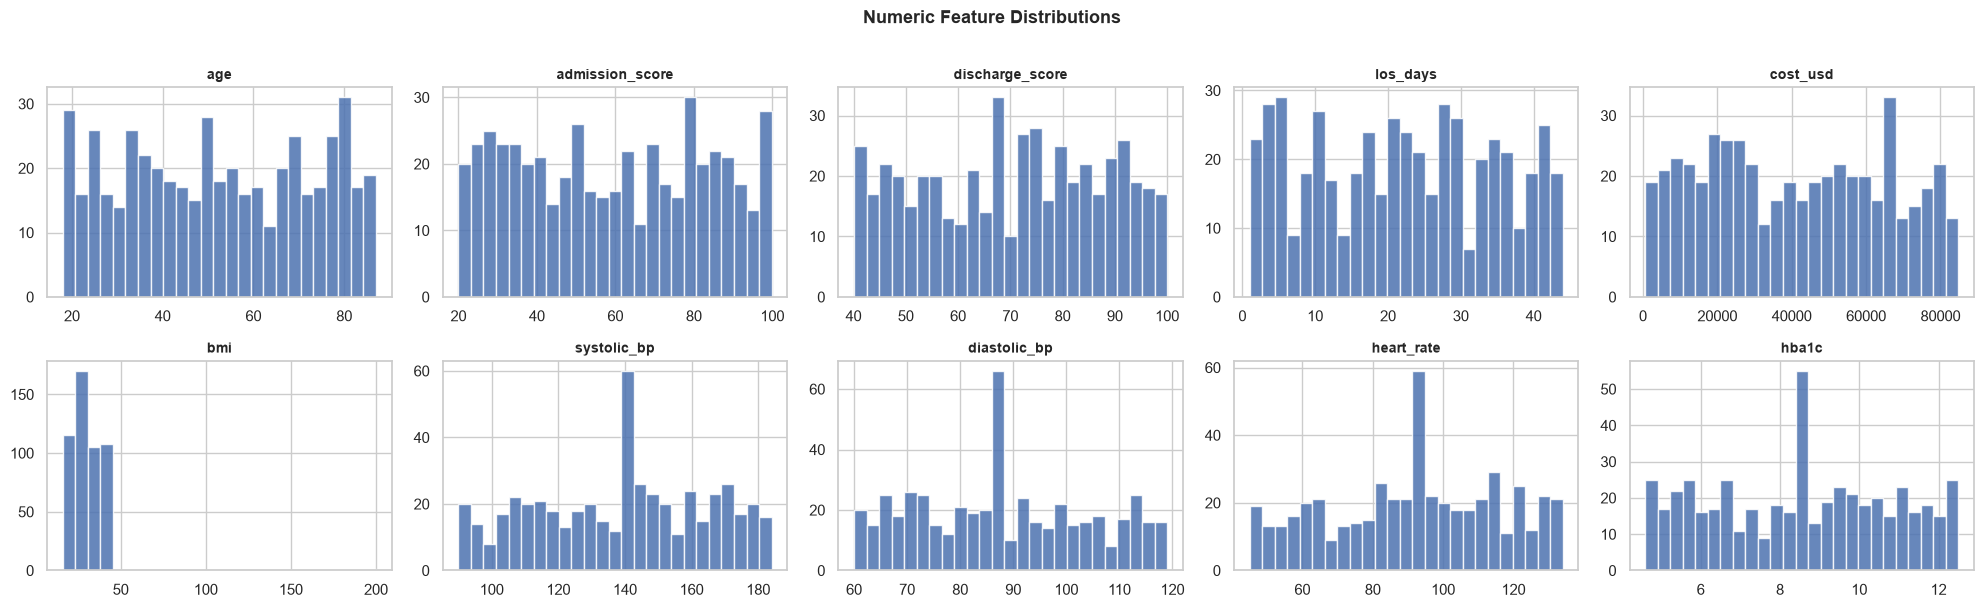

In [42]:
# Numeric distributions — all in one grid to get a gestalt view
num_cols = ["age", "admission_score", "discharge_score", "los_days",
            "cost_usd", "bmi", "systolic_bp", "diastolic_bp", "heart_rate", "hba1c"]

fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=25, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
plt.suptitle("Numeric Feature Distributions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

             diagnosis  readmit_rate  readmitted_n  total
               Anaemia      0.283019            15     53
Chronic Kidney Disease      0.245283            13     53
               Obesity      0.232558            10     43
                Asthma      0.232143            13     56
                  COPD      0.216216             8     37
          Osteoporosis      0.211538            11     52
            Depression      0.153846             8     52
    Cardiac Arrhythmia      0.140000             7     50
          Hypertension      0.137255             7     51
       Diabetes Type 2      0.115385             6     52


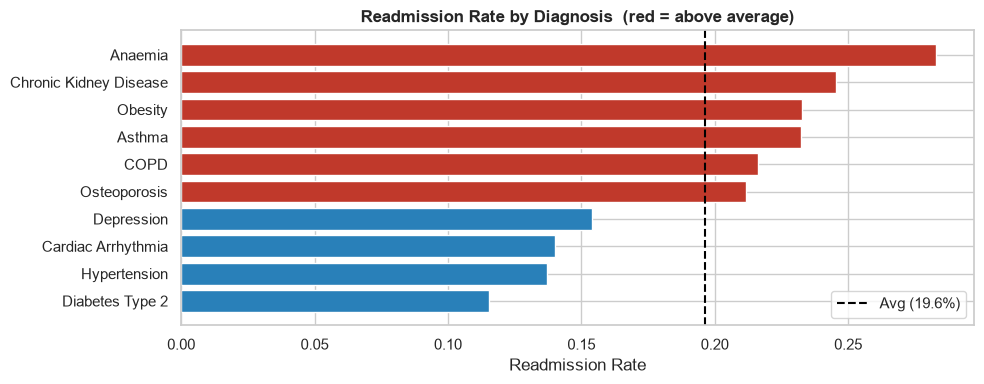

In [72]:
# Readmission rate by diagnosis
readmit_by_diag = (
    df_clean.groupby("diagnosis")["readmitted"]
    .agg(readmit_rate="mean", readmitted_n="sum", total="count")
    .sort_values("readmit_rate", ascending=False)
    .reset_index()
)
print(readmit_by_diag.to_string(index=False))

overall_avg = df_clean["readmitted"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#c0392b" if r > overall_avg else "#2980b9" for r in readmit_by_diag["readmit_rate"]]
ax.barh(readmit_by_diag["diagnosis"], readmit_by_diag["readmit_rate"], color=colors)
ax.axvline(overall_avg, color="black", linestyle="--", label=f"Avg ({overall_avg:.1%})")
ax.set_xlabel("Readmission Rate")
ax.set_title("Readmission Rate by Diagnosis  (red = above average)", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

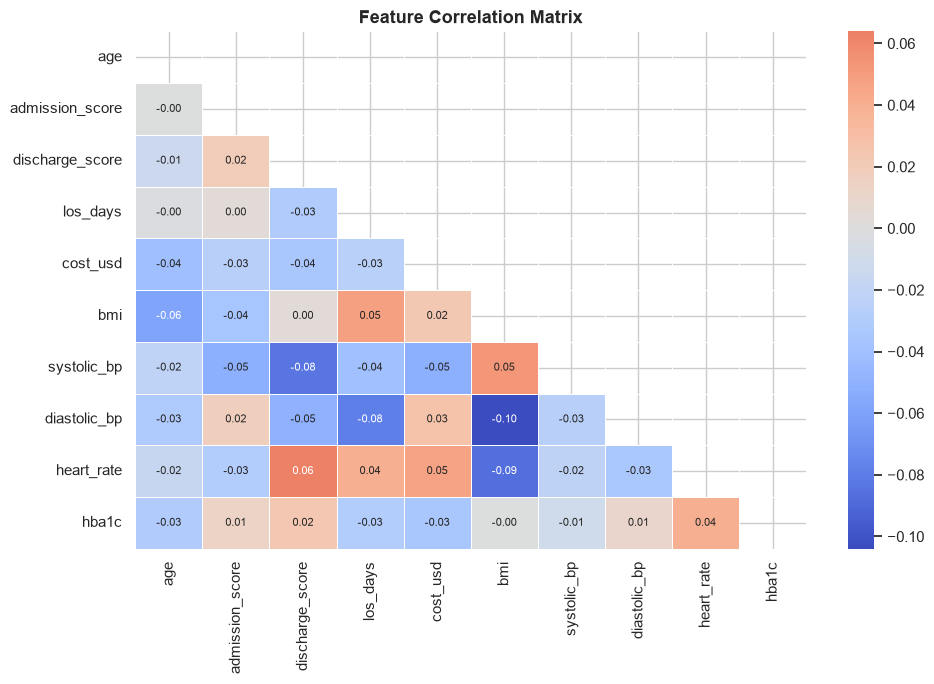

In [71]:
# Correlation heatmap
corr_cols = ["age", "admission_score", "discharge_score", "los_days",
             "cost_usd", "bmi", "systolic_bp", "diastolic_bp", "heart_rate", "hba1c"]

corr_matrix = df_clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Model prep

In [46]:
df_model = df_clean.copy()

cat_to_encode = ["gender", "diagnosis", "department", "ward"]
le = LabelEncoder()
for col in cat_to_encode:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# discharge_score is recorded after discharge — using it would be data leakage
df_model.drop(columns=["discharge_score"], inplace=True)

X = df_model.drop(columns=["readmitted"])
y = df_model["readmitted"].astype(int)

print("Feature matrix:", X.shape)
print("Features:", X.columns.tolist())
print("\nClass balance:\n", y.value_counts())

Feature matrix: (499, 13)
Features: ['age', 'gender', 'diagnosis', 'department', 'ward', 'admission_score', 'los_days', 'cost_usd', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'hba1c']

Class balance:
 readmitted
0    401
1     98
Name: count, dtype: int64


In [47]:
# stratify=y preserves the 80/20 class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale for Logistic Regression (trees don't need it)
# CRITICAL: fit on train only, transform both — never fit on full data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 399 rows | Test: 100 rows


## evalaution helper function

In [70]:
results_store = {}

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    report = classification_report(y_te, y_pred, output_dict=True)

    print(f"  MODEL: {name}")
    print(classification_report(y_te, y_pred, target_names=["Not Readmitted", "Readmitted"]))

    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["Not Readmitted", "Readmitted"], cmap="Blues"
    )
    plt.title(f"{name} — Confusion Matrix", fontweight="bold")
    plt.tight_layout(); plt.show()

    results_store[name] = {
        "Accuracy":    (y_pred == y_te).mean(),
        "Precision-1": report["1"]["precision"],
        "Recall-1":    report["1"]["recall"],
        "F1-1":        report["1"]["f1-score"],
    }
    return results_store[name]

## Model 1: Logistic Regression


`class_weight='balanced'` compensates for the 80/20 imbalance by upweighting minority-class errors.

  MODEL: Logistic Regression
                precision    recall  f1-score   support

Not Readmitted       0.81      0.47      0.60        80
    Readmitted       0.21      0.55      0.30        20

      accuracy                           0.49       100
     macro avg       0.51      0.51      0.45       100
  weighted avg       0.69      0.49      0.54       100



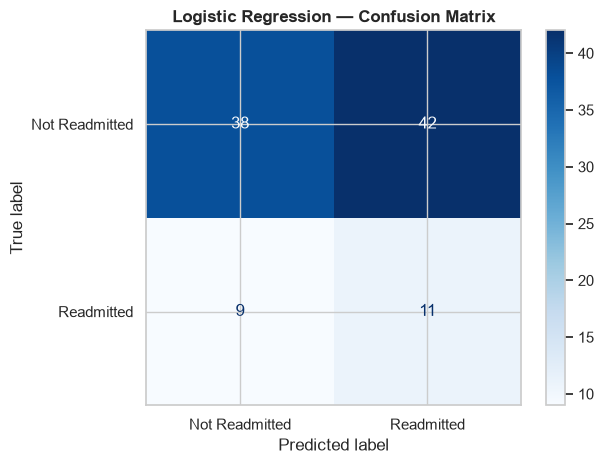

{'Accuracy': np.float64(0.49),
 'Precision-1': 0.20754716981132076,
 'Recall-1': 0.55,
 'F1-1': 0.3013698630136986}

In [53]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_sc, y_train)
evaluate("Logistic Regression", lr, X_test_sc, y_test)

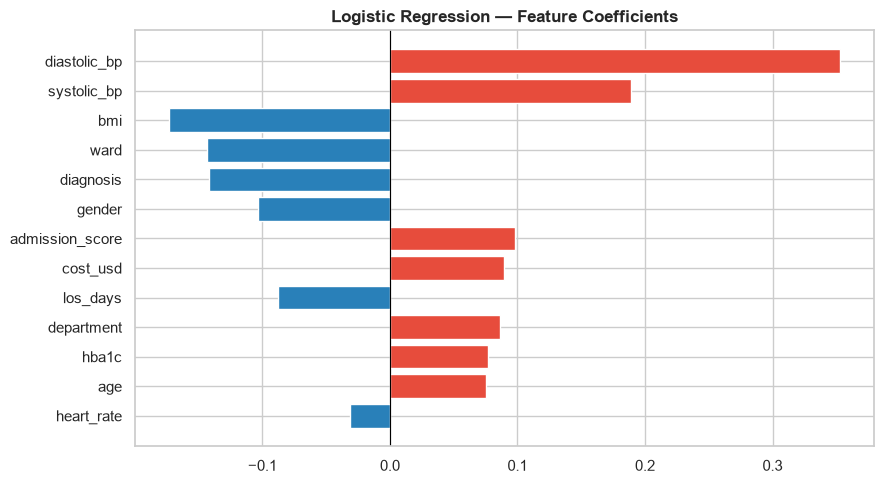

In [54]:
# Which features push readmission risk up (red) or down (blue)?
coef_df = pd.DataFrame({"feature": X.columns, "coefficient": lr.coef_[0]})\
            .sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#e74c3c" if c > 0 else "#2980b9" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression — Feature Coefficients", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

##  Model 2: Decision Tree


  MODEL: Decision Tree
                precision    recall  f1-score   support

Not Readmitted       0.92      0.44      0.59        80
    Readmitted       0.27      0.85      0.41        20

      accuracy                           0.52       100
     macro avg       0.60      0.64      0.50       100
  weighted avg       0.79      0.52      0.56       100



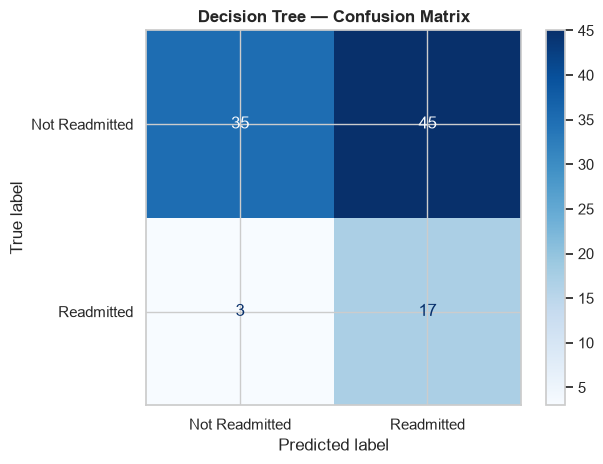

{'Accuracy': np.float64(0.52),
 'Precision-1': 0.27419354838709675,
 'Recall-1': 0.85,
 'F1-1': 0.4146341463414634}

In [55]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                             class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)
evaluate("Decision Tree", dt, X_test, y_test)

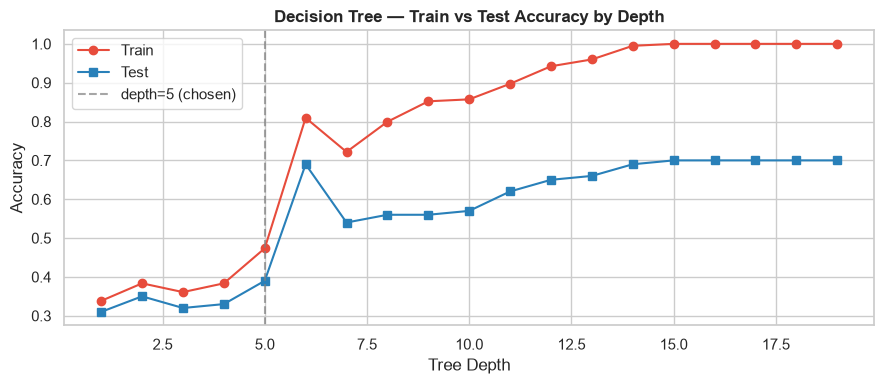

In [56]:
# Bias-variance tradeoff — watch train and test accuracy diverge at deeper depths
depths = range(1, 20)
train_accs, test_accs = [], []

for d in depths:
    tmp = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=42)
    tmp.fit(X_train, y_train)
    train_accs.append(tmp.score(X_train, y_train))
    test_accs.append(tmp.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_accs, "o-", label="Train", color="#e74c3c")
ax.plot(depths, test_accs,  "s-", label="Test",  color="#2980b9")
ax.axvline(5, color="gray", linestyle="--", alpha=0.7, label="depth=5 (chosen)")
ax.set_xlabel("Tree Depth"); ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree — Train vs Test Accuracy by Depth", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()
# After depth ~6 train keeps rising but test plateaus — classic overfitting signal.

##  Model 3: Random Forest

  MODEL: Random Forest
                precision    recall  f1-score   support

Not Readmitted       0.80      0.86      0.83        80
    Readmitted       0.21      0.15      0.18        20

      accuracy                           0.72       100
     macro avg       0.51      0.51      0.50       100
  weighted avg       0.68      0.72      0.70       100



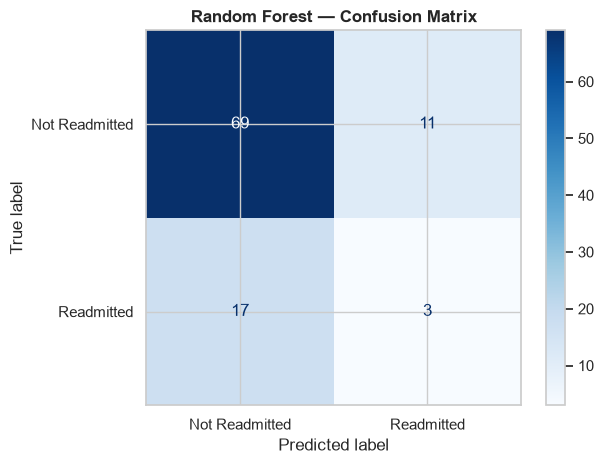

{'Accuracy': np.float64(0.72),
 'Precision-1': 0.21428571428571427,
 'Recall-1': 0.15,
 'F1-1': 0.17647058823529413}

In [57]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                             class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate("Random Forest", rf, X_test, y_test)

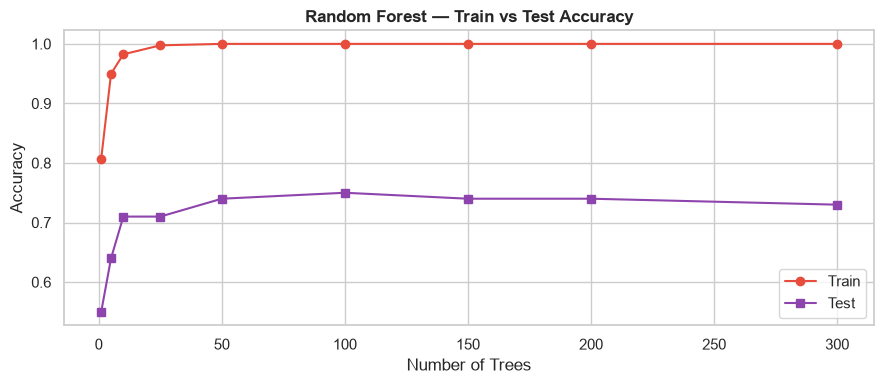

In [58]:
n_trees_range = [1, 5, 10, 25, 50, 100, 150, 200, 300]
train_accs, test_accs = [], []

for n in n_trees_range:
    tmp = RandomForestClassifier(n_estimators=n, max_depth=10, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
    tmp.fit(X_train, y_train)
    train_accs.append(tmp.score(X_train, y_train))
    test_accs.append(tmp.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_trees_range, train_accs, "o-", label="Train", color="#e74c3c")
ax.plot(n_trees_range, test_accs,  "s-", label="Test",  color="#8e44ad")
ax.set_xlabel("Number of Trees"); ax.set_ylabel("Accuracy")
ax.set_title("Random Forest — Train vs Test Accuracy", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

## Model 4: XGBoost

`scale_pos_weight` handles class imbalance: set it to the ratio of negatives to positives.

scale_pos_weight = 4.12
  MODEL: XGBoost
                precision    recall  f1-score   support

Not Readmitted       0.80      0.94      0.86        80
    Readmitted       0.17      0.05      0.08        20

      accuracy                           0.76       100
     macro avg       0.48      0.49      0.47       100
  weighted avg       0.67      0.76      0.71       100



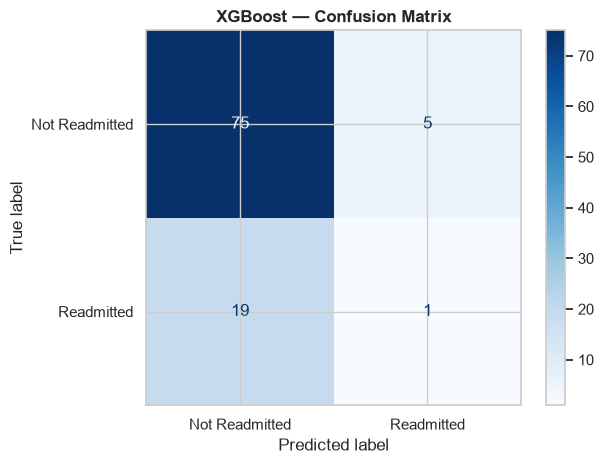

{'Accuracy': np.float64(0.76),
 'Precision-1': 0.16666666666666666,
 'Recall-1': 0.05,
 'F1-1': 0.07692307692307693}

In [59]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {neg_pos_ratio:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
evaluate("XGBoost", xgb, X_test, y_test)

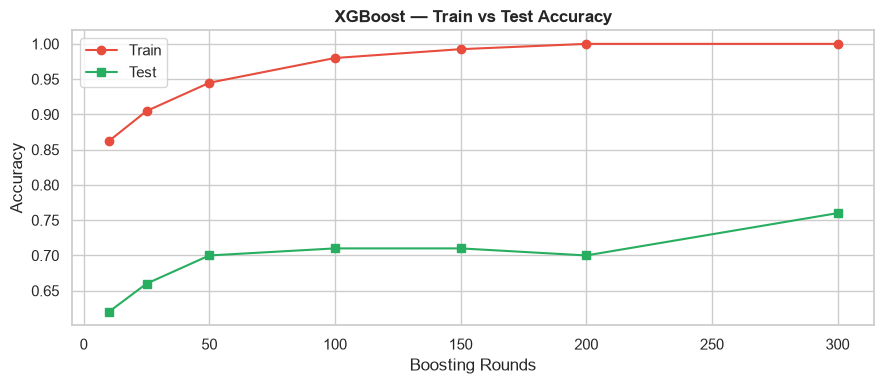

In [60]:
xgb_rounds = [10, 25, 50, 100, 150, 200, 300]
xgb_train_accs, xgb_test_accs = [], []

for n in xgb_rounds:
    tmp = XGBClassifier(
        n_estimators=n, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg_pos_ratio,
        eval_metric="logloss", random_state=42, n_jobs=-1
    )
    tmp.fit(X_train, y_train)
    xgb_train_accs.append(tmp.score(X_train, y_train))
    xgb_test_accs.append(tmp.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xgb_rounds, xgb_train_accs, "o-", label="Train", color="#e74c3c")
ax.plot(xgb_rounds, xgb_test_accs,  "s-", label="Test",  color="#27ae60")
ax.set_xlabel("Boosting Rounds"); ax.set_ylabel("Accuracy")
ax.set_title("XGBoost — Train vs Test Accuracy", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

## Testing Cross-Validation

In [62]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Logistic Regression": (lr, X_train_sc),
    "Decision Tree":        (dt, X_train),
    "Random Forest":        (rf, X_train),
    "XGBoost":              (xgb, X_train),
}

cv_results = {}
print("-" * 60)

for name, (model, X_tr) in cv_models.items():
    scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_mean = scores.mean()
    cv_std  = scores.std()
    test_acc = results_store[name]["Accuracy"]
    gap = cv_mean - test_acc
    flag = " ← overfit?" if gap > 0.05 else ""
    print(f"{name:<22} {cv_mean:>14.4f} {cv_std:>8.4f} {test_acc:>10.4f}  {gap:+.4f}{flag}")
    cv_results[name] = {"cv_mean": cv_mean, "cv_std": cv_std}

------------------------------------------------------------
Logistic Regression            0.5487   0.0804     0.4900  +0.0587 ← overfit?
Decision Tree                  0.4837   0.0335     0.5200  -0.0363
Random Forest                  0.6691   0.0655     0.7200  -0.0509
XGBoost                        0.7117   0.0490     0.7600  -0.0483


## Using GridSearchCV for Hyperparameter Tuning

In [63]:
param_grid_xgb = {
    "n_estimators":   [100, 200, 300],
    "max_depth":      [3, 4, 5],
    "learning_rate":  [0.05, 0.1],
    "subsample":      [0.7, 0.9],
}

xgb_base = XGBClassifier(
    scale_pos_weight=neg_pos_ratio,
    eval_metric="logloss", random_state=42, n_jobs=-1
)

grid_xgb = GridSearchCV(xgb_base, param_grid_xgb, cv=cv, scoring="f1", n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

print(f"\nBest params : {grid_xgb.best_params_}")
print(f"Best CV F1  : {grid_xgb.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.7}
Best CV F1  : 0.1719


In [64]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth":    [6, 8, 10],
    "min_samples_leaf": [3, 5, 10],
}

rf_base = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(rf_base, param_grid_rf, cv=cv, scoring="f1", n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

print(f"\nBest params : {grid_rf.best_params_}")
print(f"Best CV F1  : {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params : {'max_depth': 6, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV F1  : 0.2283


  MODEL: XGBoost (tuned)
                precision    recall  f1-score   support

Not Readmitted       0.80      0.93      0.86        80
    Readmitted       0.25      0.10      0.14        20

      accuracy                           0.76       100
     macro avg       0.53      0.51      0.50       100
  weighted avg       0.69      0.76      0.72       100



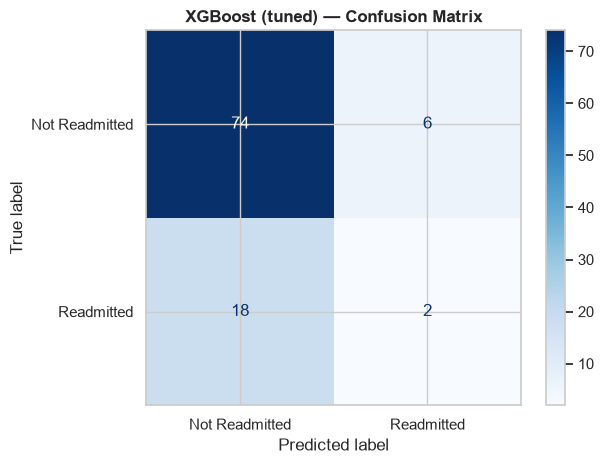

  MODEL: RF (tuned)
                precision    recall  f1-score   support

Not Readmitted       0.81      0.76      0.79        80
    Readmitted       0.24      0.30      0.27        20

      accuracy                           0.67       100
     macro avg       0.53      0.53      0.53       100
  weighted avg       0.70      0.67      0.68       100



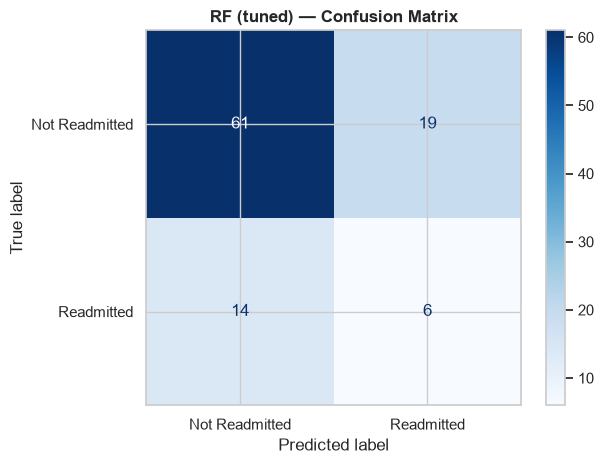

{'Accuracy': np.float64(0.67),
 'Precision-1': 0.24,
 'Recall-1': 0.3,
 'F1-1': 0.26666666666666666}

In [65]:
best_xgb = grid_xgb.best_estimator_
best_rf  = grid_rf.best_estimator_

evaluate("XGBoost (tuned)", best_xgb, X_test, y_test)
evaluate("RF (tuned)",      best_rf,  X_test, y_test)

## Chapter 14 — Feature Importance: What Actually Drives Readmission?
Comparing importances across ensemble models gives us more confidence than any single model's view.

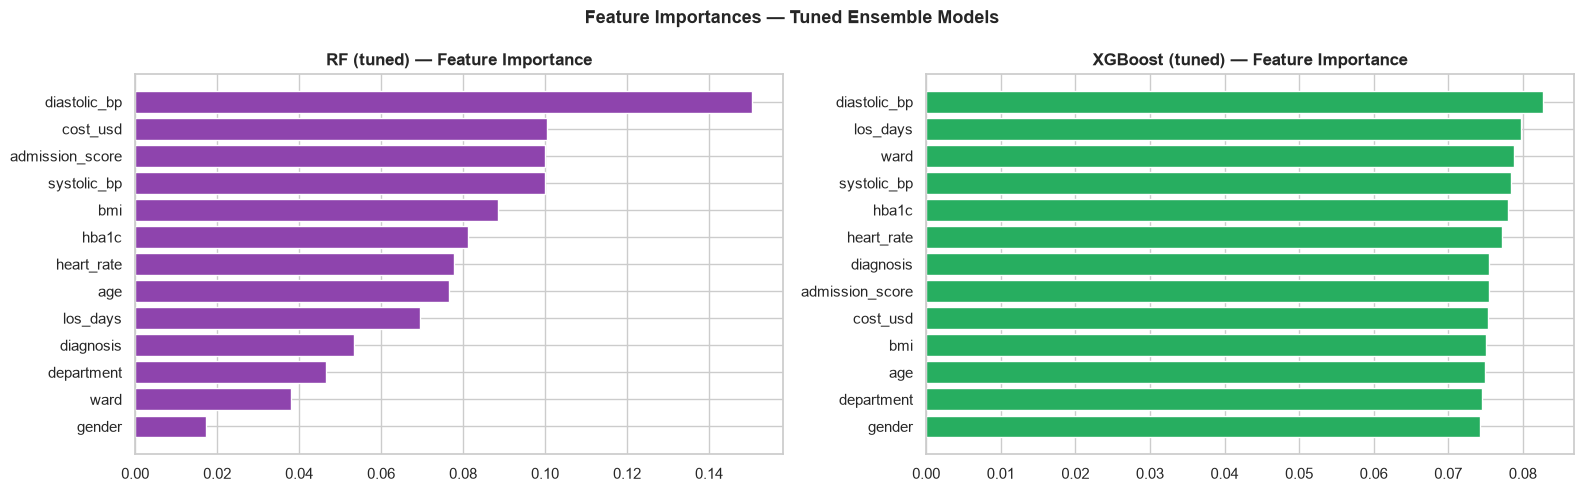

In [66]:
fi_rf_tuned  = pd.Series(best_rf.feature_importances_,  index=X.columns).sort_values(ascending=False)
fi_xgb_tuned = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(fi_rf_tuned.index,  fi_rf_tuned.values,  color="#8e44ad")
axes[0].set_title("RF (tuned) — Feature Importance",  fontweight="bold")
axes[0].invert_yaxis()

axes[1].barh(fi_xgb_tuned.index, fi_xgb_tuned.values, color="#27ae60")
axes[1].set_title("XGBoost (tuned) — Feature Importance", fontweight="bold")
axes[1].invert_yaxis()

plt.suptitle("Feature Importances — Tuned Ensemble Models", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Model's Comparison

In [69]:
comparison = pd.DataFrame(results_store).T
comparison.columns = ["Accuracy", "Precision-1", "Recall-1", "F1-1"]
comparison = comparison.round(4).sort_values("F1-1", ascending=False)

print("── Model Comparison (sorted by F1) ──")
print(comparison.to_string())

── Model Comparison (sorted by F1) ──
                     Accuracy  Precision-1  Recall-1    F1-1
Decision Tree            0.52       0.2742      0.85  0.4146
Logistic Regression      0.49       0.2075      0.55  0.3014
RF (tuned)               0.67       0.2400      0.30  0.2667
Random Forest            0.72       0.2143      0.15  0.1765
XGBoost (tuned)          0.76       0.2500      0.10  0.1429
XGBoost                  0.76       0.1667      0.05  0.0769


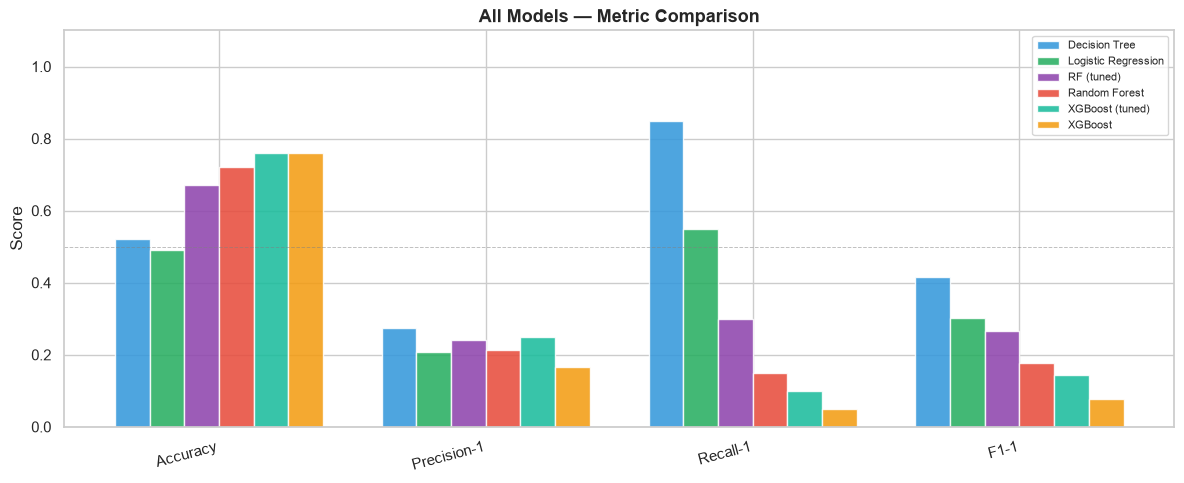

In [68]:
metrics_to_plot = ["Accuracy", "Precision-1", "Recall-1", "F1-1"]
n_models = len(comparison)
x = np.arange(len(metrics_to_plot))
width = 0.13
palette = ["#3498db", "#27ae60", "#8e44ad", "#e74c3c", "#1abc9c", "#f39c12"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(comparison.iterrows()):
    ax.bar(x + i * width, row[metrics_to_plot], width,
           label=model_name, color=palette[i % len(palette)], alpha=0.87)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metrics_to_plot, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("All Models — Metric Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout(); plt.show()